# SHAP Analysis With Original Features

This notebook is a deeper interpretability companion to the final submission notebook. It uses the real `shap` library and focuses on making the recommendation logic visible at two levels:

1. **Faithful hybrid-level SHAP**: explains the final hybrid score from the three actual inputs used by the deployed ranker: item-item KNN score, Bayesian popularity score, and genre affinity score.
2. **Original-feature SHAP through surrogate models**: explains how genres, tags, rating statistics, user profile features, and collaborative evidence relate to each component score.
3. **Content/tag SHAP**: explains a text-based movie similarity signal using title, genres, and user tags.
4. **Optional Ranking NeuMF SHAP**: explains local genre sensitivity of the ranking neural model when the trained PyTorch model is available.

Important interpretation rule: the hybrid ranker itself only consumes three numeric component scores. SHAP on those three scores is the most faithful explanation of the deployed final score. Feature-level explanations below are surrogate explanations that help us understand which original features are driving or correlating with those component scores.

## Work Plan

1. Load the final `HybridRanker`, MovieLens interactions, movie metadata, tags, and saved genre columns.
2. Build a user-movie explanation dataset containing recommended and non-recommended candidates.
3. Add original interpretable features:
   - movie genres,
   - tag indicators and tag counts,
   - movie rating statistics,
   - user rating statistics,
   - user genre profile values,
   - exact collaborative evidence from similar liked movies.
4. Run SHAP on the final hybrid formula using the real hybrid inputs.
5. Train one surrogate model per target:
   - `item_knn_score`,
   - `popularity_score`,
   - `genre_score`,
   - `hybrid_score`.
6. Use SHAP summary, bar, and waterfall plots to explain those surrogate models.
7. Run a separate content/tag SHAP analysis based on TF-IDF movie metadata.
8. Optionally run local SHAP on the Ranking NeuMF genre input.

In [1]:
from pathlib import Path
import os
import re
import sys
import warnings

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from src.hybrid_ranker import HybridRanker, DEFAULT_HYBRID_WEIGHTS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
shap.initjs()

print(f"Project root: {ROOT}")
print(f"SHAP version: {shap.__version__}")

Project root: C:\Users\rafal\OneDrive\Dokumente\GitHub\Movie-Recommendation-System-with-Explainability
SHAP version: 0.49.1


## 1. Load the Final Recommender and Raw Metadata

The final application currently uses `HybridRanker`. This object internally loads the temporal training split, the item-item KNN engine, genre columns, movie metadata, popularity scores, and user genre profiles.

In [2]:
ranker = HybridRanker()

df = ranker.item_engine.df.copy()
train_df = ranker.item_engine.train_df.copy()
genre_cols = list(ranker.item_engine.genre_cols)

raw_movies = pd.read_csv(ROOT / "data/raw/movies.csv")
raw_tags = pd.read_csv(ROOT / "data/raw/tags.csv")

print("Interactions:", df.shape)
print("Training interactions:", train_df.shape)
print("Movies:", raw_movies.shape)
print("Tags:", raw_tags.shape)
print("Genre columns:", len(genre_cols), genre_cols[:5], "...")

Interactions: (100836, 26)
Training interactions: (80896, 28)
Movies: (9742, 3)
Tags: (3683, 4)
Genre columns: 20 ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children'] ...


## 2. Build Original Feature Tables

These features are not all used directly by the deployed hybrid ranker. They are used to explain where the component scores tend to come from.

- Genre flags come from MovieLens metadata.
- Tag indicators come from user-generated MovieLens tags.
- Rating statistics summarize historical reception.
- User statistics summarize the target user's history.
- User genre profile values represent the user's historical genre preferences.

In [3]:
def extract_year(title):
    match = re.search(r"\((\d{4})\)", str(title))
    return int(match.group(1)) if match else np.nan


def build_movie_features(raw_movies, raw_tags, train_df, genre_cols, top_n_tags=30):
    movies = raw_movies.copy()
    movies["release_year"] = movies["title"].map(extract_year)
    movies["movie_age"] = movies["release_year"].max() - movies["release_year"]

    genre_lookup = ranker.item_engine.movies[genre_cols].copy()
    genre_lookup = genre_lookup.rename(columns={col: f"genre::{col}" for col in genre_cols})

    rating_stats = train_df.groupby("movieId")["rating"].agg(
        movie_rating_mean="mean",
        movie_rating_count="count",
        movie_rating_std="std",
    )
    global_mean = train_df["rating"].mean()
    smoothing = 10
    rating_stats["movie_bayesian_rating"] = (
        rating_stats["movie_rating_mean"] * rating_stats["movie_rating_count"]
        + global_mean * smoothing
    ) / (rating_stats["movie_rating_count"] + smoothing)
    rating_stats["movie_rating_std"] = rating_stats["movie_rating_std"].fillna(0.0)

    tags = raw_tags.dropna(subset=["tag"]).copy()
    tags["tag"] = tags["tag"].str.lower().str.strip()
    top_tags = tags["tag"].value_counts().head(top_n_tags).index.tolist()
    tag_sets = tags.groupby("movieId")["tag"].apply(lambda values: set(values)).to_dict()
    tag_stats = tags.groupby("movieId")["tag"].agg(
        movie_tag_count="size",
        movie_unique_tag_count=lambda values: len(set(values)),
    )

    tag_features = pd.DataFrame(index=movies["movieId"].unique())
    for tag in top_tags:
        tag_features[f"tag::{tag}"] = [
            1.0 if tag in tag_sets.get(movie_id, set()) else 0.0
            for movie_id in tag_features.index
        ]

    movie_features = (
        movies[["movieId", "title", "genres", "release_year", "movie_age"]]
        .set_index("movieId")
        .join(genre_lookup, how="left")
        .join(rating_stats, how="left")
        .join(tag_stats, how="left")
        .join(tag_features, how="left")
    )

    numeric_cols = movie_features.select_dtypes(include=[np.number]).columns
    movie_features[numeric_cols] = movie_features[numeric_cols].fillna(0.0)
    return movie_features.reset_index(), top_tags


def build_user_features(train_df, genre_cols):
    user_stats = train_df.groupby("userId")["rating"].agg(
        user_rating_count="count",
        user_rating_mean="mean",
        user_rating_std="std",
    )
    positive_rate = (
        train_df.assign(is_positive=(train_df["rating"] >= 4.0).astype(float))
        .groupby("userId")["is_positive"]
        .mean()
        .rename("user_positive_rate")
    )

    profile_rows = []
    for user_id, profile in ranker.user_genre_profiles.items():
        row = {"userId": user_id}
        row.update({f"user_pref::{genre}": float(value) for genre, value in zip(genre_cols, profile)})
        profile_rows.append(row)

    profile_df = pd.DataFrame(profile_rows).set_index("userId")
    user_features = user_stats.join(positive_rate, how="left").join(profile_df, how="left")
    user_features = user_features.fillna(0.0).reset_index()
    return user_features


movie_features, top_tags = build_movie_features(raw_movies, raw_tags, train_df, genre_cols)
user_features = build_user_features(train_df, genre_cols)

print("Movie feature table:", movie_features.shape)
print("User feature table:", user_features.shape)
print("Top tags used:", top_tags[:10])
display(movie_features.head(3))

Movie feature table: (9742, 61)
User feature table: (610, 25)
Top tags used: ['in netflix queue', 'atmospheric', 'funny', 'superhero', 'thought-provoking', 'surreal', 'disney', 'sci-fi', 'quirky', 'religion']


,movieId,title,genres,release_year,movie_age,genre::(no genres listed),genre::Action,genre::Adventure,genre::Animation,genre::Children,genre::Comedy,genre::Crime,genre::Documentary,genre::Drama,genre::Fantasy,genre::Film-Noir,genre::Horror,genre::IMAX,genre::Musical,genre::Mystery,genre::Romance,genre::Sci-Fi,genre::Thriller,genre::War,genre::Western,movie_rating_mean,movie_rating_count,movie_rating_std,movie_bayesian_rating,movie_tag_count,movie_unique_tag_count,tag::in netflix queue,tag::atmospheric,tag::funny,tag::superhero,tag::thought-provoking,tag::surreal,tag::disney,tag::sci-fi,tag::quirky,tag::religion,tag::dark comedy,tag::suspense,tag::psychology,tag::visually appealing,tag::twist ending,tag::crime,tag::comedy,tag::politics,tag::music,tag::high school,tag::mental illness,tag::dark,tag::time travel,tag::action,tag::aliens,tag::mindfuck,tag::space,tag::black comedy,tag::dreamlike,tag::shakespeare
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,23.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.915842,202.0,0.831798,3.896891,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,23.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.413043,92.0,0.918697,3.422950,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,23.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.280488,41.0,1.078476,3.326291,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Build a User-Candidate Explanation Dataset

For each sampled user, we score all unseen movies with the final hybrid ranker, keep the strongest recommendations, and add random unseen candidates. This gives SHAP both high-score and low-score examples.

In [4]:
def build_explanation_dataset(
    ranker,
    movie_features,
    user_features,
    n_users=10,
    top_per_user=30,
    random_per_user=60,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    all_items = ranker.item_engine.item_ids.tolist()
    available_users = [
        user_id for user_id in ranker.available_user_ids()
        if len(ranker.item_engine.user_seen_items.get(user_id, set())) >= 20
    ]
    selected_users = sorted(
        rng.choice(
            available_users,
            size=min(n_users, len(available_users)),
            replace=False,
        ).tolist()
    )

    rows = []
    weights = ranker.weights
    weight_sum = sum(max(value, 0.0) for value in weights.values())

    for user_id in selected_users:
        seen = ranker.item_engine.user_seen_items.get(user_id, set())
        candidate_ids = [item for item in all_items if item not in seen]
        scores, components = ranker.score_candidates(user_id, candidate_ids, weights=weights)
        ranked = sorted(candidate_ids, key=lambda item: scores[item], reverse=True)

        top_items = ranked[:top_per_user]
        remaining = np.array([item for item in candidate_ids if item not in set(top_items)])
        if len(remaining) > 0:
            random_items = rng.choice(
                remaining,
                size=min(random_per_user, len(remaining)),
                replace=False,
            ).tolist()
        else:
            random_items = []

        selected_items = list(dict.fromkeys(top_items + random_items))
        for item in selected_items:
            evidence = components["evidence"].get(item, [])
            similarities = [float(entry["similarity"]) for entry in evidence]
            rows.append(
                {
                    "userId": int(user_id),
                    "movieId": int(item),
                    "hybrid_score": float(scores[item]),
                    "item_knn_score": float(components["item_knn"].get(item, 0.0)),
                    "popularity_score": float(components["popularity"].get(item, 0.0)),
                    "genre_score": float(components["genre"].get(item, 0.0)),
                    "item_knn_contribution": weights["item_knn"] / weight_sum * float(components["item_knn"].get(item, 0.0)),
                    "popularity_contribution": weights["popularity"] / weight_sum * float(components["popularity"].get(item, 0.0)),
                    "genre_contribution": weights["genre"] / weight_sum * float(components["genre"].get(item, 0.0)),
                    "knn_evidence_count": float(len(similarities)),
                    "knn_max_similarity": float(max(similarities)) if similarities else 0.0,
                    "knn_mean_top3_similarity": float(np.mean(similarities)) if similarities else 0.0,
                }
            )

    analysis_df = pd.DataFrame(rows)
    analysis_df = analysis_df.merge(movie_features, on="movieId", how="left")
    analysis_df = analysis_df.merge(user_features, on="userId", how="left")

    numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
    analysis_df[numeric_cols] = analysis_df[numeric_cols].fillna(0.0)
    return analysis_df


analysis_df = build_explanation_dataset(ranker, movie_features, user_features)

print("Explanation dataset:", analysis_df.shape)
display(
    analysis_df[
        [
            "userId",
            "movieId",
            "title",
            "hybrid_score",
            "item_knn_score",
            "popularity_score",
            "genre_score",
            "knn_max_similarity",
            "movie_rating_count",
            "movie_bayesian_rating",
        ]
    ].sort_values("hybrid_score", ascending=False).head(10)
)

Explanation dataset: (900, 96)


,userId,movieId,title,hybrid_score,item_knn_score,popularity_score,genre_score,knn_max_similarity,movie_rating_count,movie_bayesian_rating
90,54,858,"Godfather, The (1972)",0.936001,0.920248,1.000000,0.903508,0.506361,175.0,4.260221
450,264,7153,"Lord of the Rings: The Return of the King, The...",0.922002,1.000000,0.868039,0.819971,0.843463,175.0,4.092653
91,54,2959,Fight Club (1999),0.912557,0.933785,0.984060,0.798596,0.513810,198.0,4.226639
92,54,527,Schindler's List (1993),0.908191,1.000000,0.955132,0.677631,0.550244,187.0,4.165690
93,54,608,Fargo (1996),0.907651,0.872680,0.926929,0.958315,0.480187,156.0,4.106270
540,390,6027,Dogfight (1991),0.904796,1.000000,0.645318,0.973865,0.707107,2.0,3.595072
541,390,1844,Live Flesh (Carne trémula) (1997),0.903977,1.000000,0.642044,0.973865,0.707107,3.0,3.587758
360,261,2959,Fight Club (1999),0.898828,0.827495,0.984060,0.956264,0.589827,198.0,4.226639
451,264,4993,"Lord of the Rings: The Fellowship of the Ring,...",0.893028,0.954192,0.875093,0.788636,0.804825,185.0,4.108415
810,518,2973,Crimes and Misdemeanors (1989),0.887574,0.986811,0.707967,0.868707,0.526361,14.0,3.735036


## 4. Actual SHAP for the Final Hybrid Formula

This is the most faithful SHAP analysis for the deployed final model because the hybrid score really is a weighted sum of these three model scores.

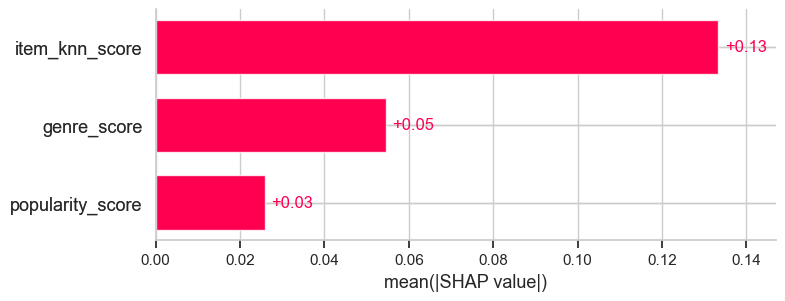

In [5]:
HYBRID_FEATURES = ["item_knn_score", "popularity_score", "genre_score"]
weights = DEFAULT_HYBRID_WEIGHTS.copy()
weight_sum = sum(weights.values())


def predict_hybrid(values):
    values = np.asarray(values)
    return (
        values[:, 0] * weights["item_knn"] / weight_sum
        + values[:, 1] * weights["popularity"] / weight_sum
        + values[:, 2] * weights["genre"] / weight_sum
    )


X_hybrid = analysis_df[HYBRID_FEATURES].astype(float)
background_hybrid = X_hybrid.sample(min(100, len(X_hybrid)), random_state=42)
hybrid_explainer = shap.Explainer(
    predict_hybrid,
    shap.maskers.Independent(background_hybrid),
    feature_names=HYBRID_FEATURES,
)

X_hybrid_sample = X_hybrid.sample(min(200, len(X_hybrid)), random_state=7)
hybrid_shap = hybrid_explainer(X_hybrid_sample)

shap.plots.bar(hybrid_shap, max_display=3)

,userId,movieId,title,hybrid_score,item_knn_score,popularity_score,genre_score
90,54,858,"Godfather, The (1972)",0.936001,0.920248,1.0,0.903508


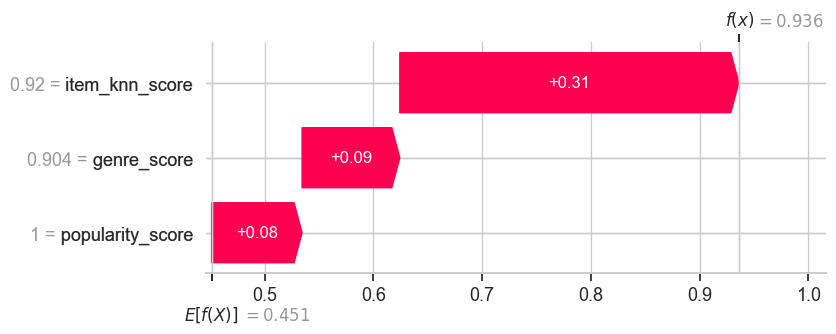

In [6]:
local_idx = analysis_df["hybrid_score"].idxmax()
local_row = analysis_df.loc[[local_idx], HYBRID_FEATURES].astype(float)
local_shap = hybrid_explainer(local_row)

display(analysis_df.loc[[local_idx], ["userId", "movieId", "title", "hybrid_score"] + HYBRID_FEATURES])
shap.plots.waterfall(local_shap[0], max_display=3)

## 5. Original-Feature SHAP for Separate Component Models

The next cells train small surrogate models. Each surrogate learns to reproduce one score from interpretable original features. This lets us ask:

- Which features explain high `item_knn_score`?
- Which features explain high `popularity_score`?
- Which features explain high `genre_score`?
- Which original features best approximate the final `hybrid_score`?

Before interpreting SHAP, always check the surrogate quality. If `R2` is weak, the SHAP plot is only a rough correlation story.

In [7]:
genre_feature_cols = [f"genre::{genre}" for genre in genre_cols]
tag_feature_cols = [col for col in analysis_df.columns if col.startswith("tag::")]
user_pref_cols = [col for col in analysis_df.columns if col.startswith("user_pref::")]

rating_feature_cols = [
    "movie_rating_mean",
    "movie_rating_count",
    "movie_rating_std",
    "movie_bayesian_rating",
    "movie_tag_count",
    "movie_unique_tag_count",
    "release_year",
    "movie_age",
    "user_rating_count",
    "user_rating_mean",
    "user_rating_std",
    "user_positive_rate",
    "knn_evidence_count",
    "knn_max_similarity",
    "knn_mean_top3_similarity",
]

original_feature_cols = (
    rating_feature_cols
    + genre_feature_cols
    + user_pref_cols
    + tag_feature_cols
)

X_original = analysis_df[original_feature_cols].astype(float).fillna(0.0)

print("Original feature count:", len(original_feature_cols))
print("Genres:", len(genre_feature_cols), "| User profile genres:", len(user_pref_cols), "| Tags:", len(tag_feature_cols))

Original feature count: 85
Genres: 20 | User profile genres: 20 | Tags: 30


In [8]:
def fit_surrogate(target_col, X, analysis_df, random_state=42):
    y = analysis_df[target_col].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=random_state,
    )

    model = ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = {
        "target": target_col,
        "rows": len(X),
        "features": X.shape[1],
        "r2": r2_score(y_test, predictions),
        "mae": mean_absolute_error(y_test, predictions),
    }

    X_explain = X_test.sample(min(200, len(X_test)), random_state=random_state)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_explain)

    importance = (
        pd.DataFrame(
            {
                "feature": X_explain.columns,
                "mean_abs_shap": np.abs(shap_values).mean(axis=0),
            }
        )
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    return {
        "model": model,
        "metrics": metrics,
        "explainer": explainer,
        "X_explain": X_explain,
        "shap_values": shap_values,
        "importance": importance,
    }


targets = ["item_knn_score", "popularity_score", "genre_score", "hybrid_score"]
surrogate_results = {
    target: fit_surrogate(target, X_original, analysis_df)
    for target in targets
}

metrics_df = pd.DataFrame([result["metrics"] for result in surrogate_results.values()])
display(metrics_df)

,target,rows,features,r2,mae
0,item_knn_score,900,85,0.999001,0.005551
1,popularity_score,900,85,0.998330,0.003251
2,genre_score,900,85,0.904925,0.052666
3,hybrid_score,900,85,0.974325,0.025245


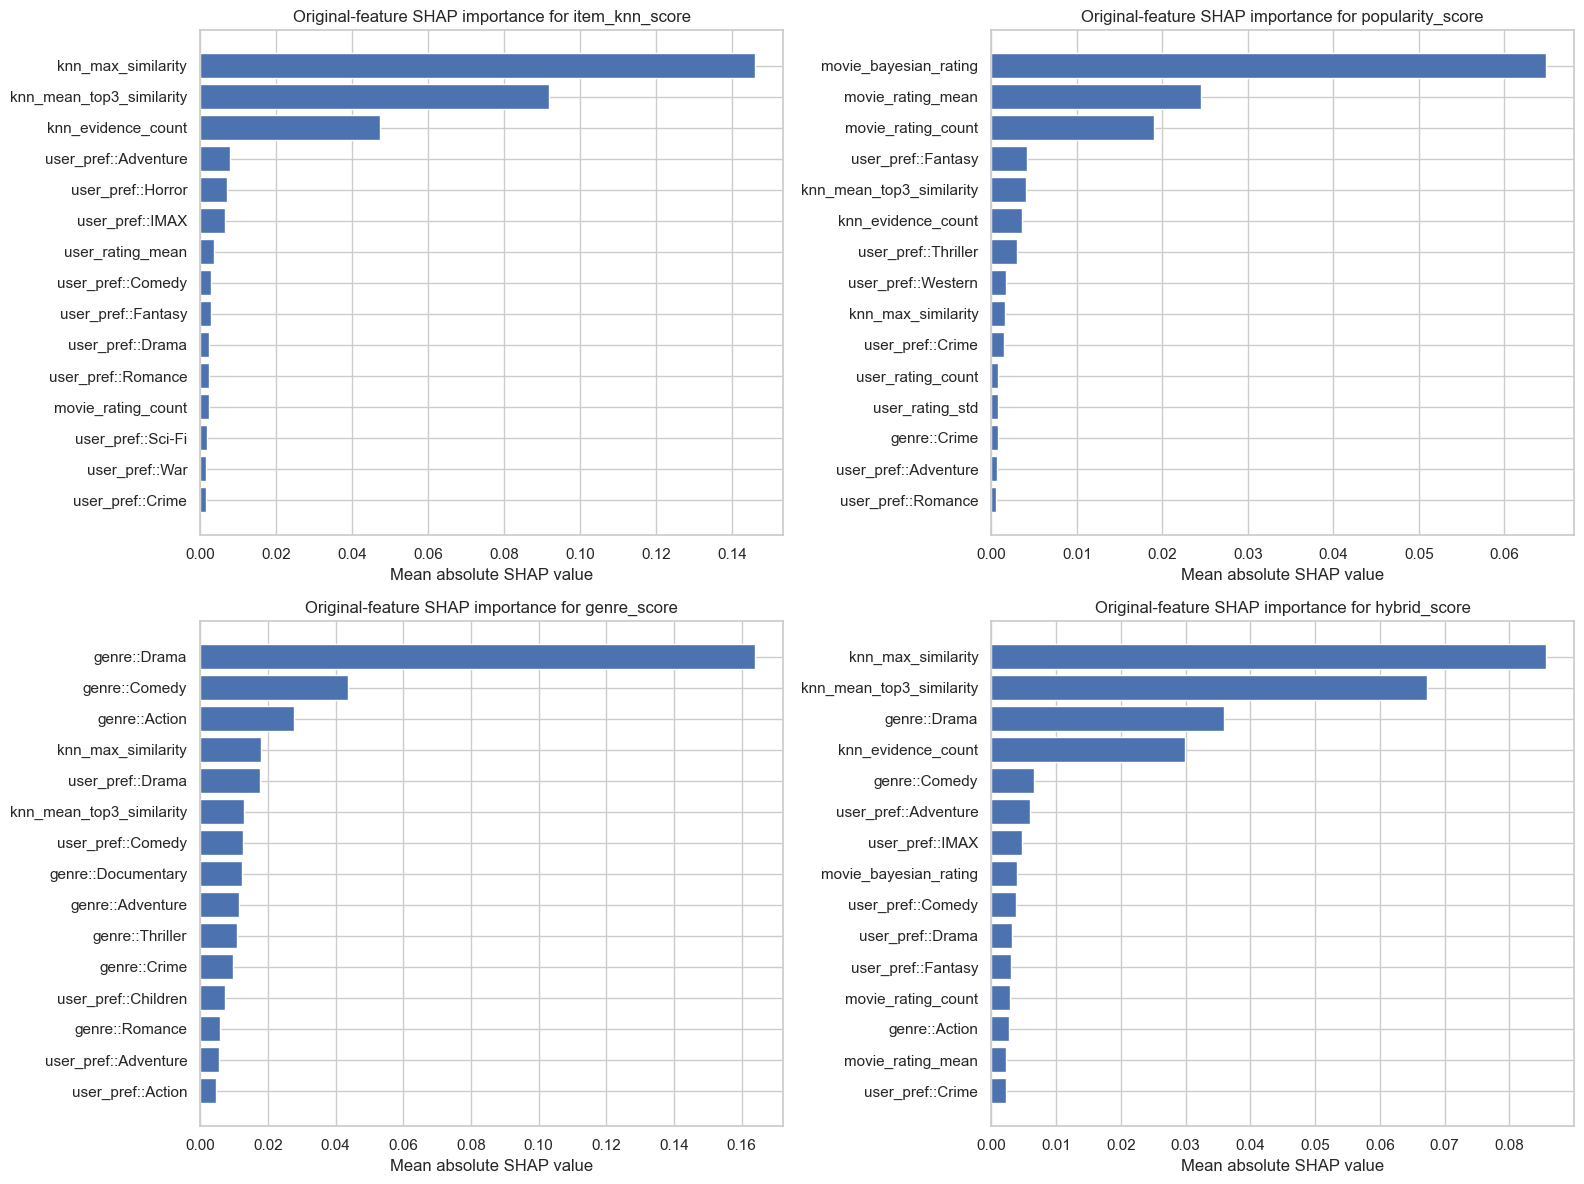

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, target in zip(axes, targets):
    top = surrogate_results[target]["importance"].head(15).iloc[::-1]
    ax.barh(top["feature"], top["mean_abs_shap"])
    ax.set_title(f"Original-feature SHAP importance for {target}")
    ax.set_xlabel("Mean absolute SHAP value")

plt.tight_layout()
plt.show()

Surrogate metrics: {'target': 'hybrid_score', 'rows': 900, 'features': 85, 'r2': 0.9743248385733789, 'mae': 0.02524488243638779}


,feature,mean_abs_shap
0,knn_max_similarity,0.085702
1,knn_mean_top3_similarity,0.067216
2,genre::Drama,0.035859
3,knn_evidence_count,0.029857
4,genre::Comedy,0.006507
5,user_pref::Adventure,0.005914
6,user_pref::IMAX,0.004785
7,movie_bayesian_rating,0.003918
8,user_pref::Comedy,0.003732
9,user_pref::Drama,0.003192


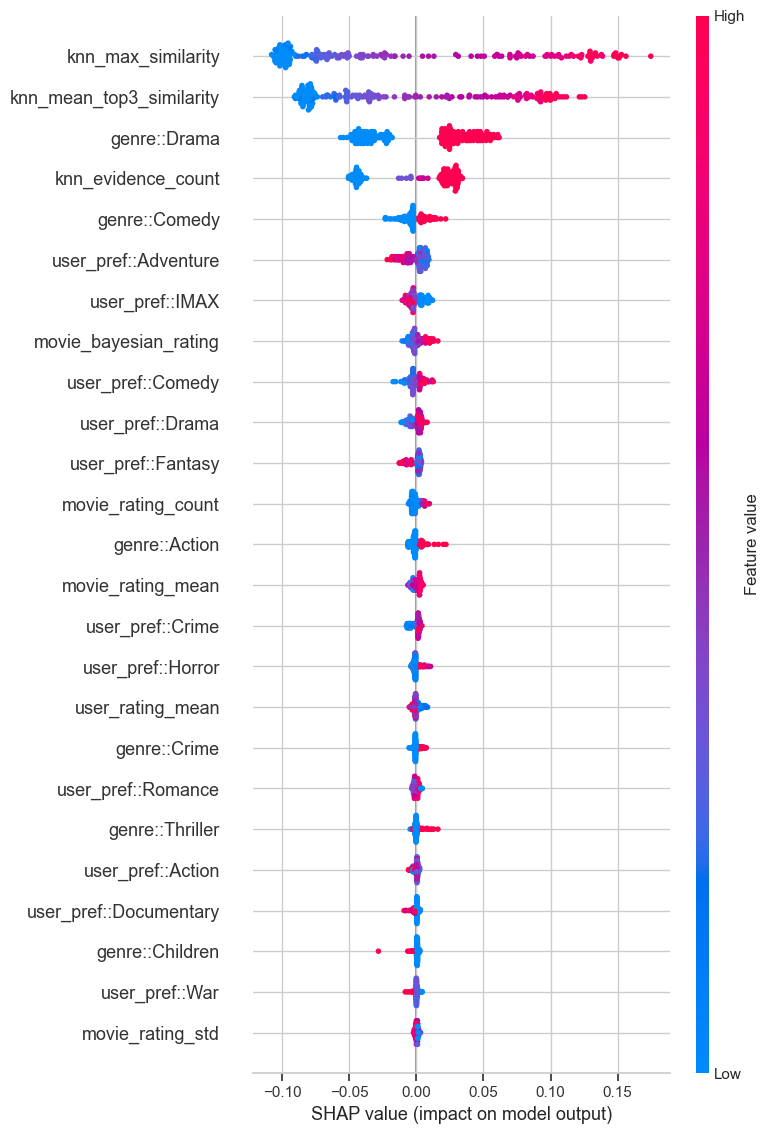

In [10]:
target_to_plot = "hybrid_score"  # Try: item_knn_score, popularity_score, genre_score, hybrid_score
result = surrogate_results[target_to_plot]

print("Surrogate metrics:", result["metrics"])
display(result["importance"].head(25))

shap.summary_plot(
    result["shap_values"],
    result["X_explain"],
    max_display=25,
    show=True,
)

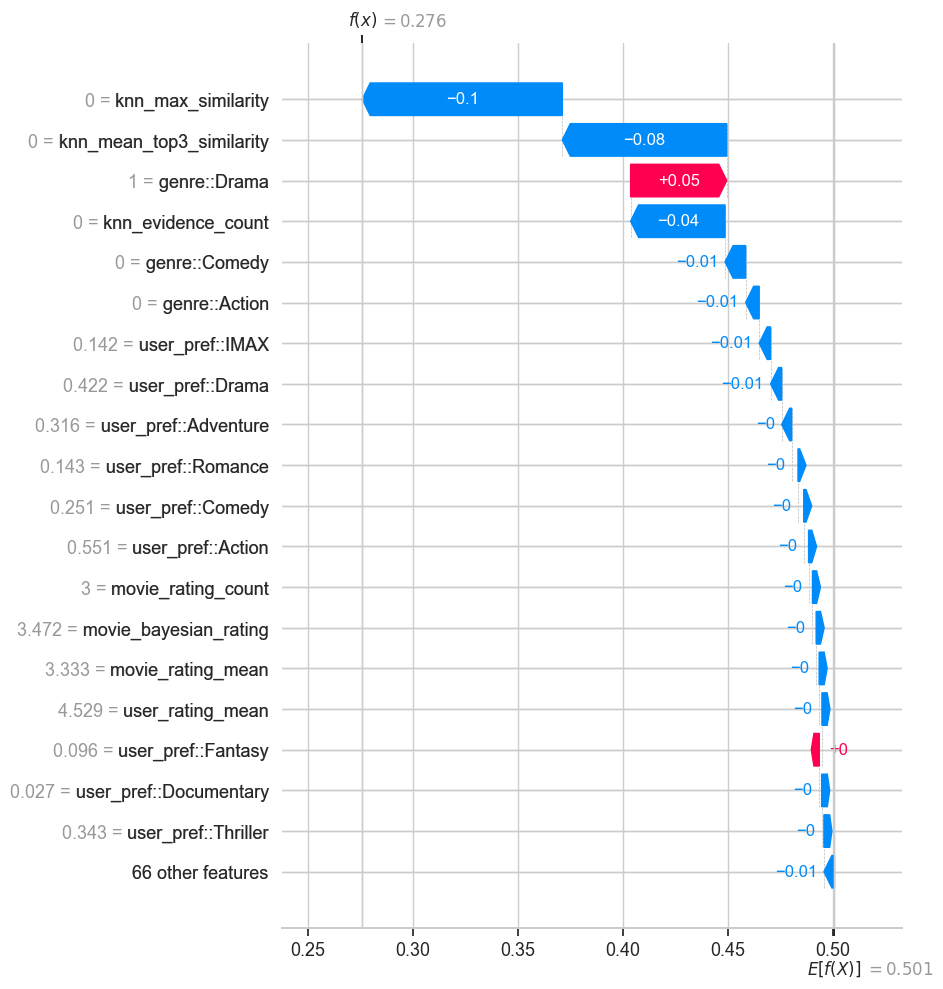

In [11]:
local_target = "hybrid_score"
result = surrogate_results[local_target]
local_pos = 0

shap.plots.waterfall(
    shap.Explanation(
        values=result["shap_values"][local_pos],
        base_values=result["explainer"].expected_value,
        data=result["X_explain"].iloc[local_pos].values,
        feature_names=result["X_explain"].columns.tolist(),
    ),
    max_display=20,
)

## 6. Content and Tag SHAP

This section explains a text/content similarity signal using title, genres, and MovieLens user tags. It is useful for understanding tag and metadata semantics, especially for users or movies where collaborative history is sparse.

Seed movie: Godfather, The (1972)


,movieId,title,genres,tag_text,content_similarity
1422,1945,On the Waterfront (1954),Crime|Drama,boxing coulda been a contender,1.0
3809,5333,Bob le Flambeur (1955),Crime|Drama,,1.0
5439,25963,"Young and the Damned, The (Olvidados, Los) (1950)",Crime|Drama,,1.0
5462,26151,Au Hasard Balthazar (1966),Crime|Drama,donkey,1.0
9714,188675,Dogman (2018),Crime|Drama,,1.0
5410,25788,Scarface (1932),Crime|Drama,,1.0
5408,25773,Little Caesar (1931),Crime|Drama,,1.0
659,858,"Godfather, The (1972)",Crime|Drama,mafia,1.0
5026,7820,"Virgin Spring, The (Jungfrukällan) (1960)",Crime|Drama,,1.0
5094,8042,Mean Streets (1973),Crime|Drama,,1.0


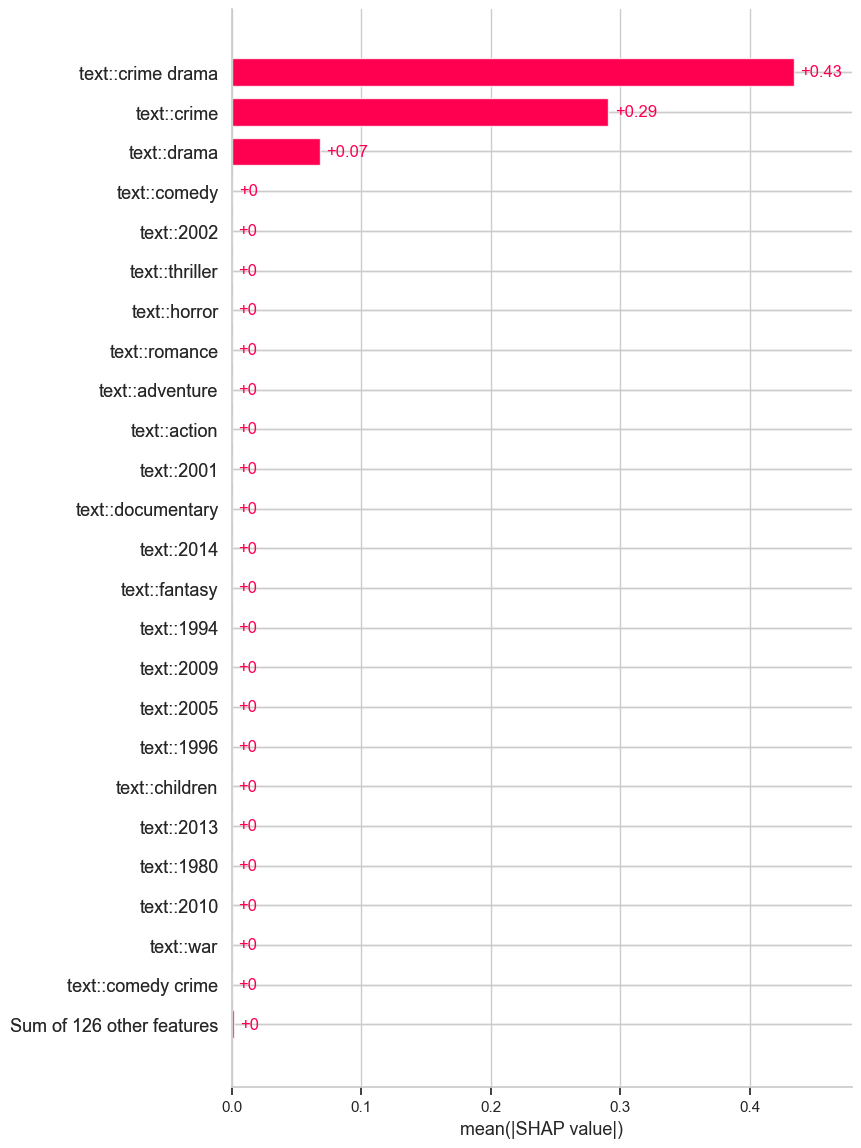

In [12]:
tags_clean = raw_tags.dropna(subset=["tag"]).copy()
tags_clean["tag"] = tags_clean["tag"].str.lower().str.strip()
tag_text = tags_clean.groupby("movieId")["tag"].apply(lambda values: " ".join(values)).rename("tag_text")

content_df = raw_movies.merge(tag_text, on="movieId", how="left")
content_df["tag_text"] = content_df["tag_text"].fillna("")
content_df["metadata"] = (
    content_df["title"].fillna("")
    + " "
    + content_df["genres"].str.replace("|", " ", regex=False).str.lower().fillna("")
    + " "
    + content_df["tag_text"]
)

seed_movie_id = int(analysis_df.sort_values("hybrid_score", ascending=False).iloc[0]["movieId"])
seed_title = content_df.loc[content_df["movieId"] == seed_movie_id, "title"].iloc[0]
seed_index = content_df.index[content_df["movieId"] == seed_movie_id][0]

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=150,
    min_df=2,
    ngram_range=(1, 2),
)
tfidf_matrix = tfidf.fit_transform(content_df["metadata"])
content_similarity = cosine_similarity(tfidf_matrix[seed_index], tfidf_matrix).ravel()

text_feature_names = [f"text::{term}" for term in tfidf.get_feature_names_out()]
X_text = pd.DataFrame(tfidf_matrix.toarray(), columns=text_feature_names)

content_model = Ridge(alpha=1.0)
content_model.fit(X_text, content_similarity)

background_text = X_text.sample(min(250, len(X_text)), random_state=42)
text_explainer = shap.LinearExplainer(content_model, background_text)

top_similar_indices = np.argsort(content_similarity)[-40:][::-1]
X_text_explain = X_text.iloc[top_similar_indices]
text_shap = text_explainer(X_text_explain)

content_preview = content_df.iloc[top_similar_indices][["movieId", "title", "genres", "tag_text"]].copy()
content_preview["content_similarity"] = content_similarity[top_similar_indices]

print("Seed movie:", seed_title)
display(content_preview.head(10))
shap.plots.bar(text_shap, max_display=25)

Waterfall for the most content-similar movie to the seed:


,movieId,title,genres,tag_text,content_similarity
1422,1945,On the Waterfront (1954),Crime|Drama,boxing coulda been a contender,1.0


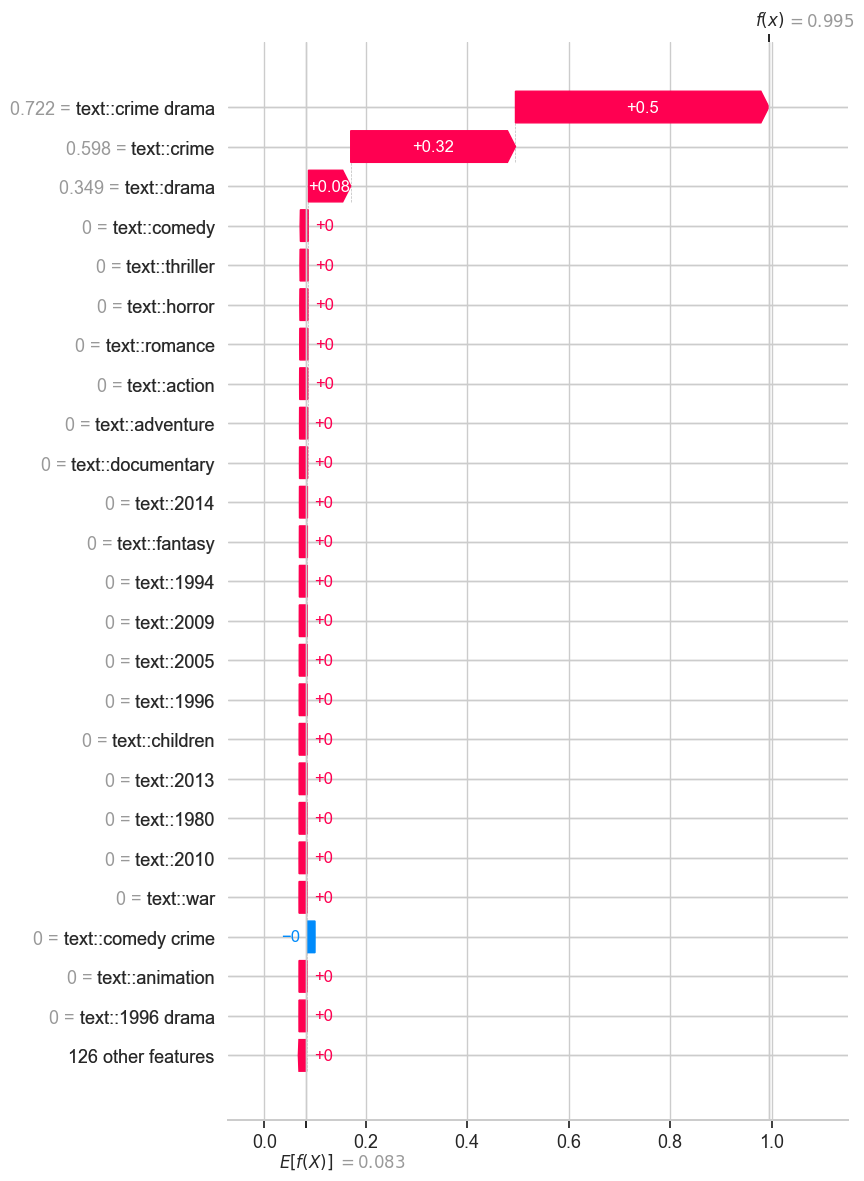

In [13]:
print("Waterfall for the most content-similar movie to the seed:")
display(content_preview.head(1))
shap.plots.waterfall(text_shap[0], max_display=25)

## 7. Optional Ranking NeuMF Genre SHAP

Ranking NeuMF contains user and item embeddings, which are not directly human-readable. However, it also receives explicit genre features. The cell below fixes one user and one movie identity, then asks how changing the explicit genre vector would affect the neural ranking logit.

This is a local sensitivity explanation, not a complete explanation of the hidden embedding space.

Fixed user: 54
Fixed movie: Godfather, The (1972)


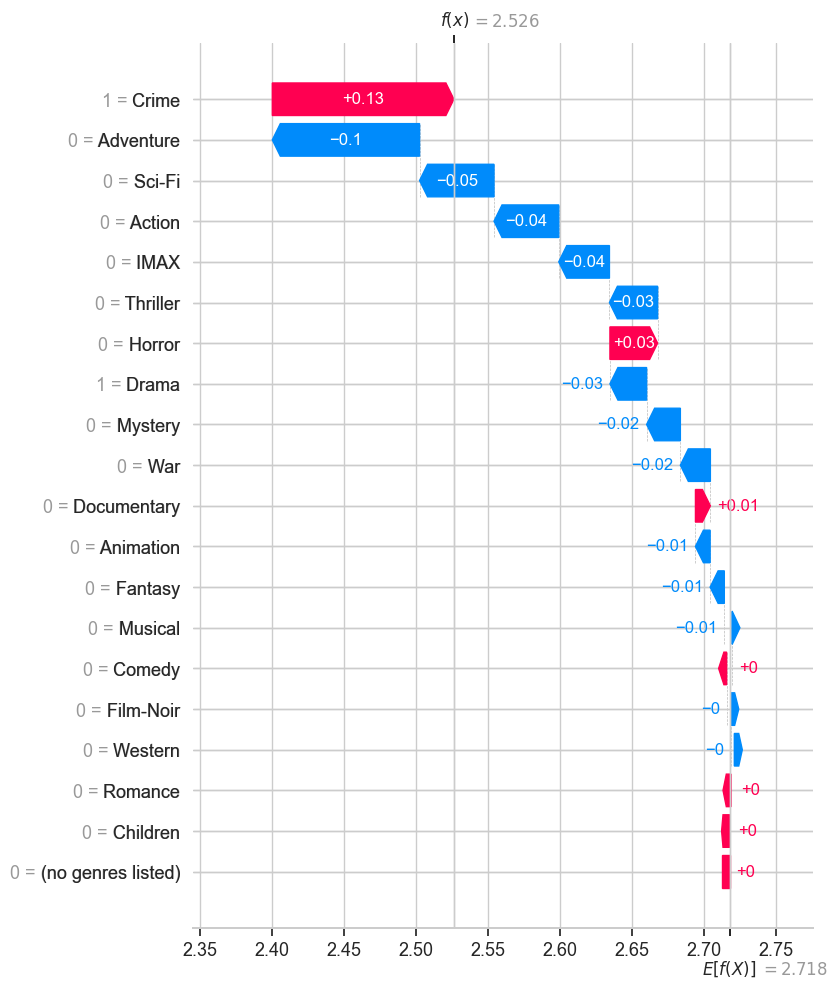

In [14]:
try:
    import torch
    from src.evaluation import _load_neumf_ranking_model, safe_transform

    neumf_bundle = _load_neumf_ranking_model(df, genre_cols)
except Exception as exc:
    print("Could not load Ranking NeuMF:", repr(exc))
    neumf_bundle = None

if neumf_bundle is None:
    print("Ranking NeuMF artifacts are unavailable, so this section is skipped.")
else:
    selected = analysis_df.sort_values("hybrid_score", ascending=False).iloc[0]
    fixed_user_id = int(selected["userId"])
    fixed_movie_id = int(selected["movieId"])

    device = neumf_bundle["device"]
    model = neumf_bundle["model"]
    user_encoder = neumf_bundle["user_encoder"]
    item_encoder = neumf_bundle["item_encoder"]
    movie_lookup = neumf_bundle["movie_lookup"]
    neural_genre_cols = list(neumf_bundle["genre_cols"])

    background_genres = (
        movie_lookup[neural_genre_cols]
        .drop_duplicates()
        .sample(min(30, movie_lookup[neural_genre_cols].drop_duplicates().shape[0]), random_state=42)
        .to_numpy(dtype=np.float32)
    )
    target_genres = movie_lookup.loc[[fixed_movie_id], neural_genre_cols].to_numpy(dtype=np.float32)

    fixed_user_encoded = safe_transform(user_encoder, np.array([fixed_user_id]))[0]
    fixed_item_encoded = safe_transform(item_encoder, np.array([fixed_movie_id]))[0]

    def predict_neumf_from_genres(genre_matrix):
        genre_matrix = np.asarray(genre_matrix, dtype=np.float32)
        n_rows = genre_matrix.shape[0]
        user_tensor = torch.tensor([fixed_user_encoded] * n_rows, dtype=torch.long, device=device)
        item_tensor = torch.tensor([fixed_item_encoded] * n_rows, dtype=torch.long, device=device)
        genre_tensor = torch.tensor(genre_matrix, dtype=torch.float32, device=device)
        with torch.no_grad():
            return model(user_tensor, item_tensor, genre_tensor).detach().cpu().numpy()

    neural_explainer = shap.Explainer(
        predict_neumf_from_genres,
        background_genres,
        feature_names=neural_genre_cols,
        algorithm="permutation",
    )
    neural_shap = neural_explainer(
        target_genres,
        max_evals=2 * len(neural_genre_cols) + 1,
    )

    print("Fixed user:", fixed_user_id)
    print("Fixed movie:", movie_lookup.loc[fixed_movie_id, "title"])
    shap.plots.waterfall(neural_shap[0], max_display=20)

## 8. How to Use This Notebook in the Final Project

Recommended final interpretation:

- Use section 4 as the faithful explanation of the deployed hybrid ranker.
- Use section 5 to discuss feature-level drivers:
  - popularity should be explained mostly by rating count and Bayesian rating,
  - genre score should be explained by genre flags and user genre preferences,
  - item-item KNN should be explained most faithfully by similar liked movies, while surrogate SHAP can show metadata patterns correlated with collaborative similarity.
- Use section 6 to discuss tags and semantic metadata as a cold-start-friendly explanation layer.
- Use section 7 only as a neural sensitivity analysis, because NeuMF embeddings are powerful but less transparent.

The safest reporting language is: "SHAP on the hybrid components is faithful to the deployed score; SHAP on original features is a surrogate explanation that reveals interpretable drivers and correlations."